In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import folium
from folium.plugins import HeatMap
import numpy as np
import os


In [12]:
# Load similarity scores (Adjust filenames as necessary)
jaccard_df = pd.read_csv("../Task 6 - Tika-Similarity/tika-files/Jaccard/jaccard_scores.csv")  # Jaccard similarity scores
edit_df = pd.read_csv("../Task 6 - Tika-Similarity/tika-files/Edit_distance/edit_scores.csv")  # Edit distance scores
cosine_df = pd.read_csv("../Task 6 - Tika-Similarity/tika-files/Cosine/cosine_scores.csv")  # Edit distance scores

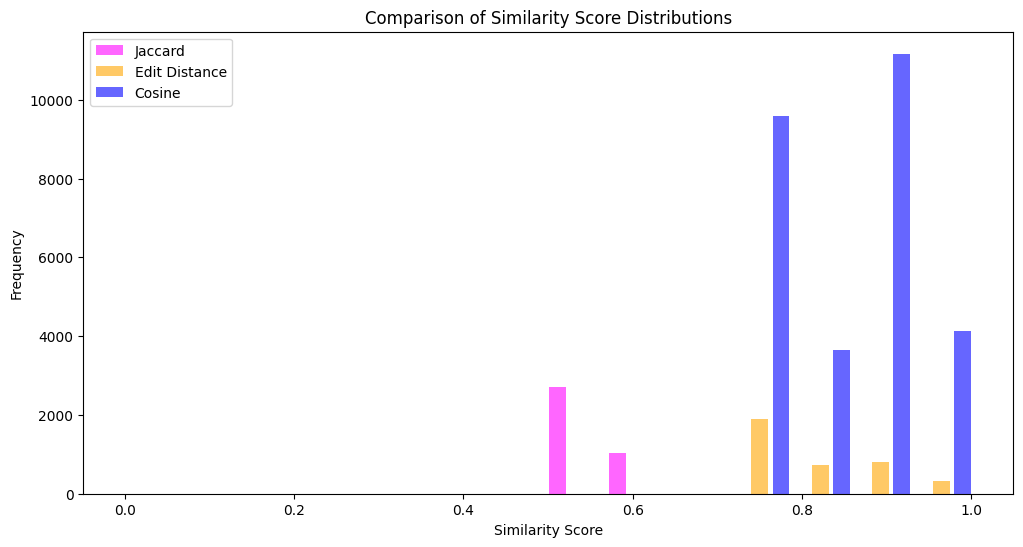

In [50]:
def plot_spaced_vertical_similarity_bars(jaccard_df, edit_df, cosine_df):
    plt.figure(figsize=(12, 6))

    # Define bins for uniform alignment
    bins = np.linspace(0, 1, 15)  # Fewer bins for better readability

    # Create histograms but store frequency counts to use as bars
    jaccard_counts, bin_edges = np.histogram(jaccard_df["Similarity_score"], bins=bins)
    edit_counts, _ = np.histogram(edit_df["Similarity_score"], bins=bins)
    cosine_counts, _ = np.histogram(cosine_df["Similarity_score"], bins=bins)

    # Calculate bin centers for positioning the bars
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Define bar width and spacing
    bar_width = 0.02  # Makes bars thinner for readability
    spacing = 0.025  # Space between different similarity methods

    # Create vertical bars with spacing
    plt.bar(bin_centers - spacing, jaccard_counts, width=bar_width, color="magenta", label="Jaccard", alpha=0.6)
    plt.bar(bin_centers, edit_counts, width=bar_width, color="orange", label="Edit Distance", alpha=0.6)
    plt.bar(bin_centers + spacing, cosine_counts, width=bar_width, color="blue", label="Cosine", alpha=0.6)

    # Labels and title
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.title("Comparison of Similarity Score Distributions")
    plt.legend()

    # Define save path
    save_path = os.path.join("../Task 6 - Tika-Similarity/data/similarity_score_distribution.png")

    # Save the figure as PNG
    plt.savefig(save_path, bbox_inches="tight", dpi=300)

    # Show the plot
    plt.show()

# Run the function
plot_spaced_vertical_similarity_bars(jaccard_df, edit_df, cosine_df)


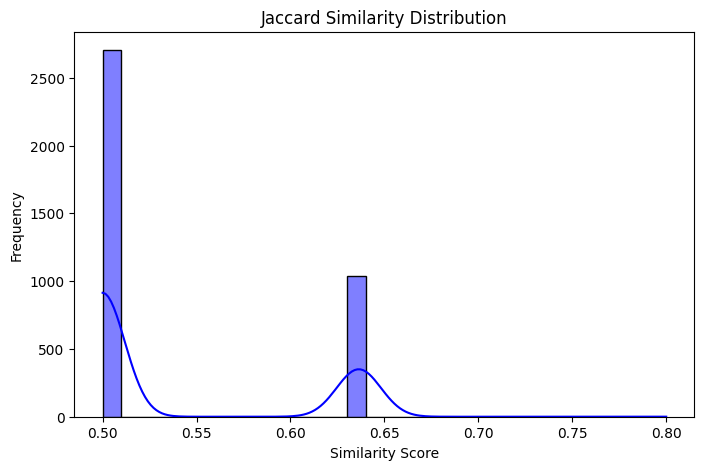

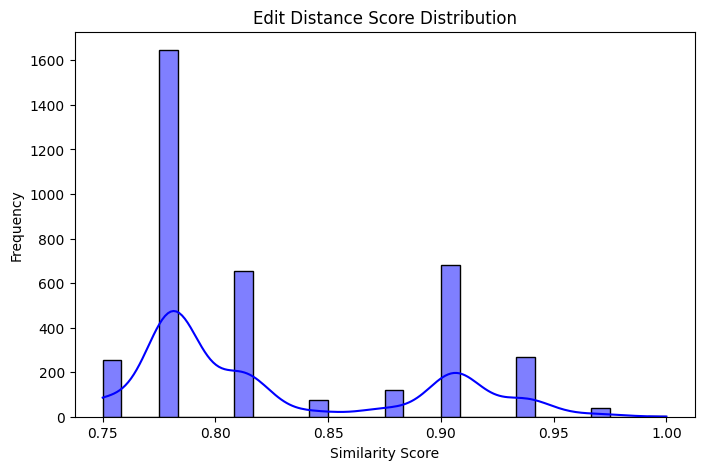

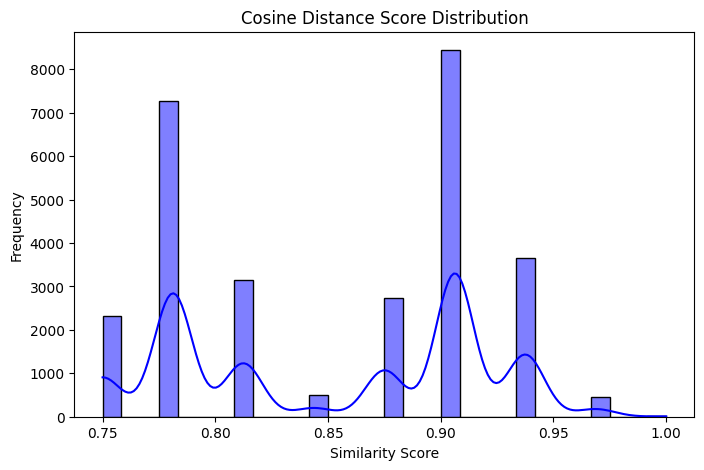

In [40]:
# Define function to plot and save similarity score distributions
def plot_similarity_distribution(df, column, title, save_path):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=30, kde=True, color="blue")
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.title(title)

    # Save the figure as PNG before showing
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    
    plt.show()  # Show after saving

# Define save path
save_path_jaccard = os.path.join("../Task 6 - Tika-Similarity/data/Jaccard Similarity Distribution.png")
save_path_edit = os.path.join("../Task 6 - Tika-Similarity/data/Edit Distance Score Distribution.png")
save_path_cosine = os.path.join("../Task 6 - Tika-Similarity/data/Cosine Distance Score Distribution.png")

# Plot and save each similarity distribution
plot_similarity_distribution(jaccard_df, "Similarity_score", "Jaccard Similarity Distribution", save_path_jaccard)
plot_similarity_distribution(edit_df, "Similarity_score", "Edit Distance Score Distribution", save_path_edit)
plot_similarity_distribution(cosine_df, "Similarity_score", "Cosine Distance Score Distribution", save_path_cosine)


In [56]:
# Load dataset (adjust file path if necessary)
df = pd.read_csv("../data/final_haunted_places (1).tsv", sep="\t")

/var/folders/z5/vfx1x7n1717bc2w84z8xwftw0000gn/T/ipykernel_29640/2106398405.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette="Blues_r")


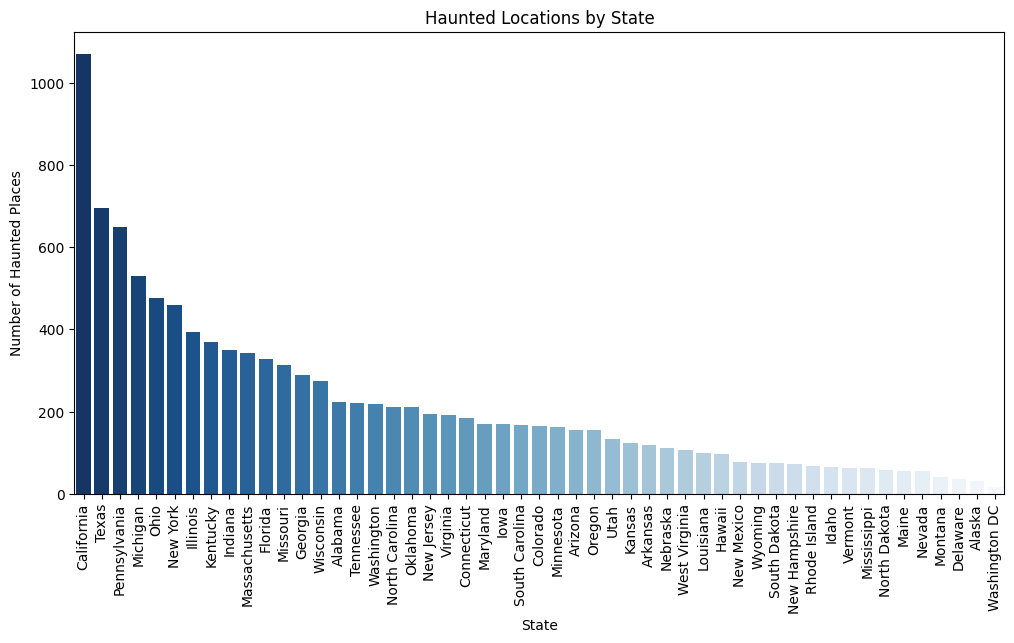

In [44]:
# Define function to plot and save Haunted Locations by State
def plot_haunted_by_state(save_path):
    state_counts = df["state_abbrev"].value_counts()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=state_counts.index, y=state_counts.values, palette="Blues_r")
    plt.xlabel("State")
    plt.ylabel("Number of Haunted Places")
    plt.title("Haunted Locations by State")
    plt.xticks(rotation=90)

    # Save the figure before showing
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    
    plt.show()  # Display after saving

# Define save path
save_path_state = os.path.join("../Task 6 - Tika-Similarity/data/Haunted Locations by State.png")

# Call the function with the save path
plot_haunted_by_state(save_path_state)


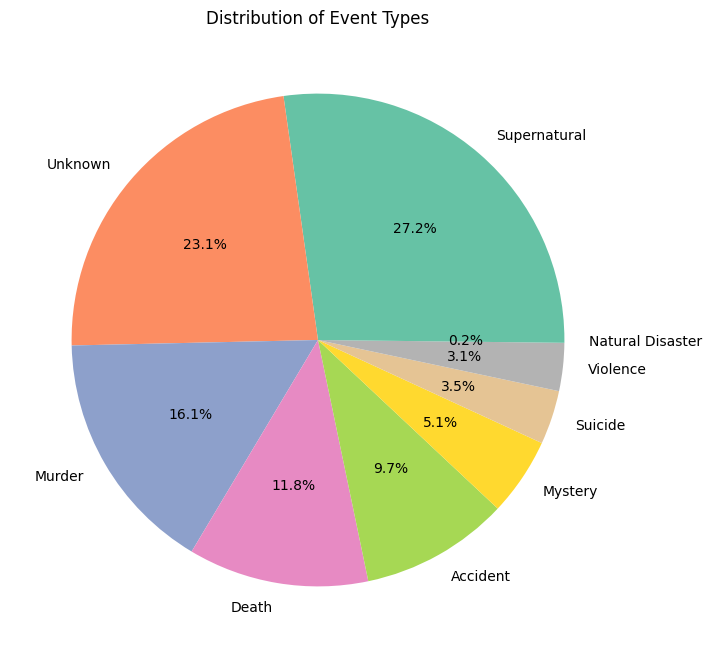

In [49]:
### 2. Type of Hauntings (Pie Chart)
def plot_haunting_types(save_path):
    if "Event Type" in df.columns:
        haunting_counts = df["Event Type"].value_counts()
        plt.figure(figsize=(8, 8))
        plt.pie(haunting_counts, labels=haunting_counts.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
        plt.title("Distribution of Event Types")

        # Save the figure before showing
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.show()
    
# Define save path
save_path_state = os.path.join("../Task 6 - Tika-Similarity/data/Distribution of Event Types.png")

plot_haunting_types(save_path_state)


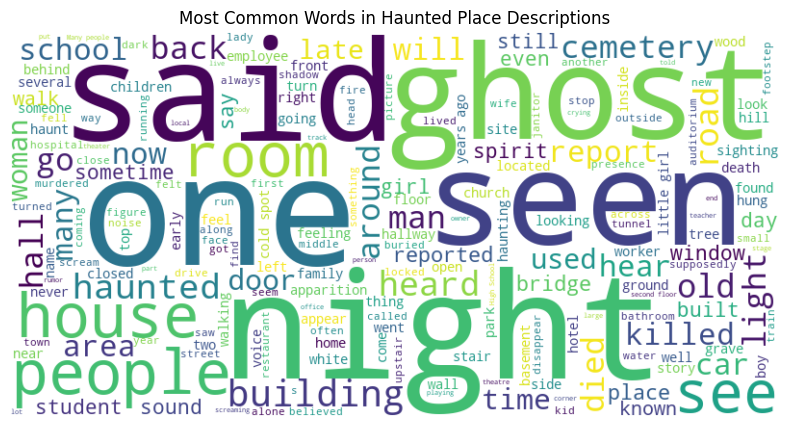

In [51]:
# Define function to generate and save the Word Cloud
def generate_wordcloud(save_path):
    text = " ".join(df["description"].dropna())  # Assuming 'description' column exists

    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Most Common Words in Haunted Place Descriptions")

    # Save the figure before showing
    plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()  # Display after saving

# Define save path
save_path_wordcloud = os.path.join("../Task 6 - Tika-Similarity/data/Word_Cloud_Haunted_Places.png")

# Call the function with the save path
generate_wordcloud(save_path_wordcloud)
